In [5]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
connection=sqlite3.connect('superstore.db') #SQLite bazasina qosuluruq

In [7]:
# 5 ci sorgunun nəticəsini görmək üçün bele yaza bilerik,
#python oz ozune sql emrlerini oxuya bilmediyi ucun sorgunu dirnaq icinde yaziriq
query_q5 = """
SELECT region,category,sub_category,
ROUND(SUM(sales), 2) AS total_sales,
ROUND(SUM(profit), 2) AS total_profit,
ROUND(SUM(profit) / SUM(sales), 4) AS profit_margin
FROM orders
GROUP BY region, category, sub_category
ORDER BY total_profit ASC;
"""
#bu emrle dirnaq icindeki metni bazaya otururuk ve baza hemin metni oxuyub icra edir
df_q5 = pd.read_sql(query_q5, connection)
df_q5.head() # head le ilk 5 setre baxa bilirik

,region,category,sub_category,total_sales,total_profit,profit_margin
0,East,Furniture,Tables,39139.81,-11025.38,-0.2817
1,South,Furniture,Tables,43916.19,-4623.06,-0.1053
2,Central,Furniture,Furnishings,15254.37,-3906.22,-0.2561
3,Central,Furniture,Tables,39154.97,-3559.65,-0.0909
4,Central,Office Supplies,Appliances,23582.03,-2638.62,-0.1119


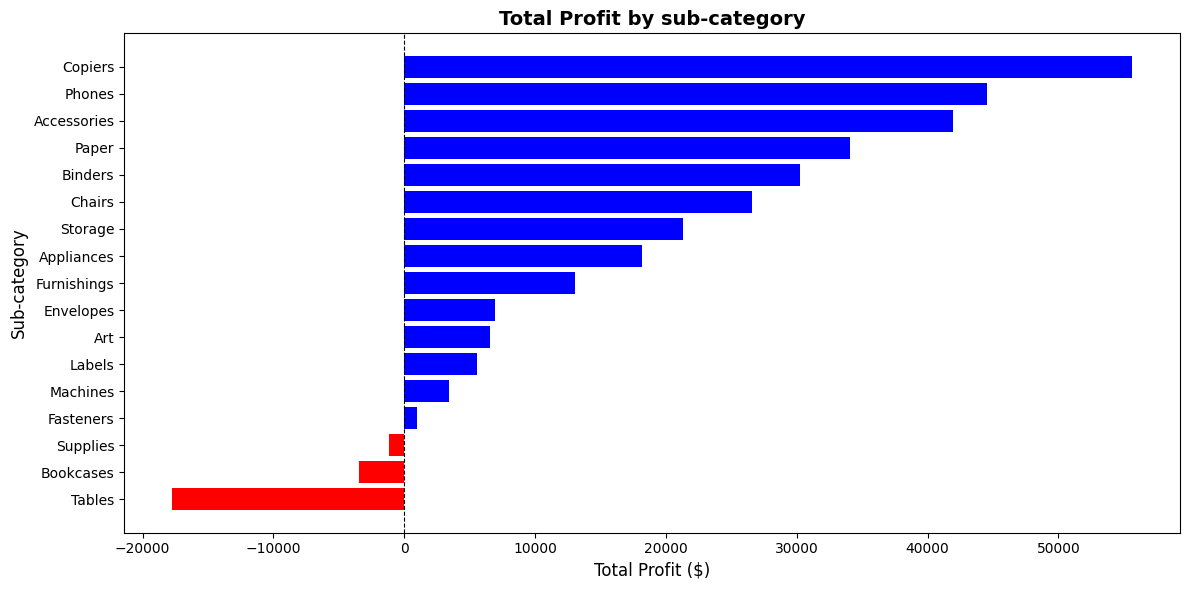

In [8]:
query_subcat='''
select sub_category,sum(profit) as total_profit
from orders
group by sub_category
order by total_profit asc;
'''
df_subcat=pd.read_sql(query_subcat,connection)
#qrafikin qurulmasi
plt.figure(figsize=(12,6))
#menfi deyerler qirmizi,musbetler mavi olmalidir
#burada her bir alt kateqoriyanin profitine p desek her defe dovrde p ni yoxlayir menfidirse qirmizi eks halda mavi yazir
colors=['red' if p<0 else 'blue' for p in df_subcat['total_profit']]
#barh horizontal bar demekdir bele yazanda sutundur ufuqi sekilde duzulur ,sadece bar yazsaq saquli formada olacaqdi
bars=plt.barh(df_subcat['sub_category'],df_subcat['total_profit'], color=colors)
#burada ise x oxunda asagidan yuxariya qara nazik qiriq qiriq xett cekilir,zererde olanlar 0 dan solda gelirli olanlar 0 dan sagda yerlesir
plt.axvline(0,color='black',linewidth=0.8, linestyle='--')
plt.title('Total Profit by sub-category',fontsize=14,fontweight='bold') #fontsize sriftin olcusunu gosterir
plt.xlabel('Total Profit ($)',fontsize=12)
plt.ylabel('Sub-category',fontsize=12)
plt.tight_layout() # qrafikde kenarlardan kesilmenin qarsisini alir seliqeli yazir
plt.show()


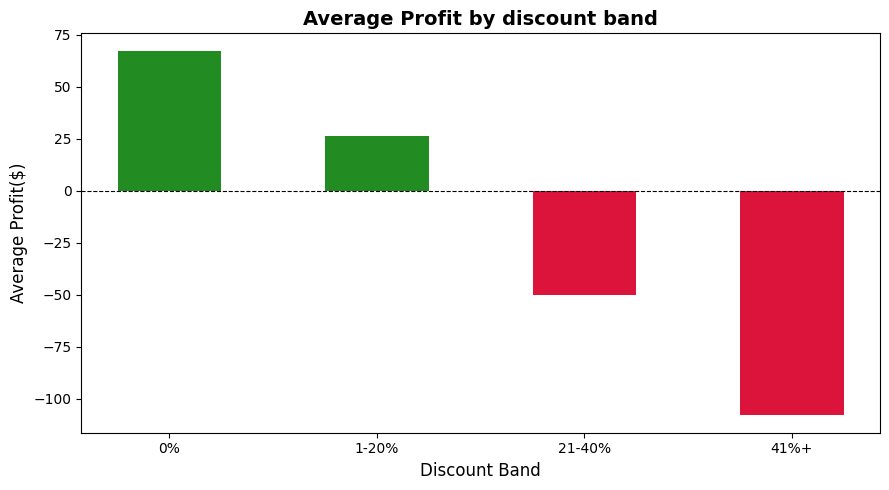

In [13]:
#Q7 sorgusu
query_discount='''select case when discount=0 then '0%'
when discount>0 and discount<=0.20 then '1-20%'
when discount>0.20 and discount<0.40 then '21-40%'
else '41%+'
end as discount_band,
round(avg(profit),2) as avg_profit
from orders
group by discount_band
order by discount asc;'''
df_discount=pd.read_sql(query_discount,connection)
#qrafikin qurulmasi
plt.figure(figsize=(9,5))
colors_discount=['forestgreen' if p>0 else 'crimson' for p in df_discount['avg_profit']]
bars=plt.bar(df_discount['discount_band'],df_discount['avg_profit'],color=colors_discount,width=0.5)
plt.axhline(0,color='black',linewidth=0.8,linestyle='--')
plt.title('Average Profit by discount band',fontsize=14,fontweight='bold')
plt.xlabel('Discount Band',fontsize=12)
plt.ylabel('Average Profit($)',fontsize=12)
plt.tight_layout()
plt.show()

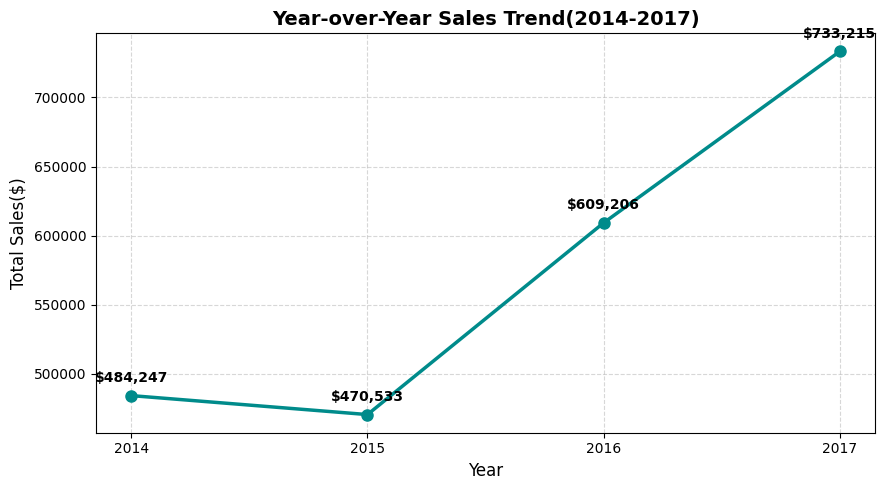

In [19]:
#Q8 sorgusu
query_yoy='''with yearly_sales As (select substr(order_date,-4) as year,sum(sales) as total_sales
from orders
group by year) -- date dən ili çıxardırıq(sondan 4 rəqəmi kəsərək) və illərə görə satışları qruplaşdırıb subquery yaradırıq
select year,total_sales,
lag(total_sales,1) over (order by year asc) as previous_year_sales--lag əvvəlki sətri cari sətrin yanına gətirir
from yearly_sales;'''
df_yoy=pd.read_sql(query_yoy,connection)

plt.figure(figsize=(9,5))
#plot x oxunda iller ,y oxunda satislar olmaqla linechart yaradir,marker illerin kesisdiyi noqtelere kicik daireler qoyur,xetlerin rengi firuzeyi olacaq,markersize ise dairelerin olcusudur
plt.plot(df_yoy['year'],df_yoy['total_sales'],marker='o',color='darkcyan',linewidth=2.5,markersize=8)
#enumerate satislar arasinda sirayla gezir, hem elementin indeksini(i) hem de ozunu(txt) goturur
#annotate her hansi bir noqteye yazi elave etmek ucundur
#funksiyayla reqemlerin qarsisina dollar isaresi qoyulacaq ve minlik ayirici kimi vergul istifade olunacaq
#yazilan yazi xettin yada noqtenin ustune dusmesin deye xytextle 10 piksel yuxari surusdururuk
#ha horizontal alignment demekdir metnin istiqametini teyin edir center yazanda merkezlesdirir
for i,txt in enumerate(df_yoy['total_sales']):plt.annotate(f"${txt:,.0f}",(df_yoy['year'][i],df_yoy['total_sales'][i]),textcoords='offset points',xytext=(0,10),
ha='center',fontsize=10,fontweight='bold')
plt.title('Year-over-Year Sales Trend(2014-2017)',fontsize=14,fontweight='bold')
plt.xlabel('Year',fontsize=12)
plt.ylabel('Total Sales($)',fontsize=12)
plt.grid(True,linestyle='--',alpha=0.5) # grid arxa fona tor xetleri elave edir, alpha xetlerin gorunurluk derecesini gosterir
plt.tight_layout()
plt.show()

In [27]:
#bonus proof
df_orders=pd.read_sql('Select * from orders',connection) # butun cedveli pandasa cekirik
df_orders['order_date']=pd.to_datetime(df_orders['order_date']) #tarixleri datetime formatina ceviririk
df_orders['ship_date']=pd.to_datetime(df_orders['ship_date'])
df_orders['days_to_ship']=(df_orders['ship_date']-df_orders['order_date']).dt.days #nece gune catdirilmasina baxiriq,dt.days cixdigimiz zaman yaranan saat deqiqe ferqini gun sayina cevirir
pandas_result=df_orders.groupby('ship_mode')['days_to_ship'].mean().reset_index() #catdirilma gunlerinin orta qiymetini her bir dasinma novune gore qruplasdirir,reset index ise indekslenmis sutune normal sutuna qaytarir
pandas_result

,ship_mode,days_to_ship
0,First Class,2.182705
1,Same Day,0.044199
2,Second Class,3.238046
3,Standard Class,5.006535
